In [1]:
!pip install -Uqq fastbook
!pip install -Uqq fastai
!pip install -Uqq ddgs

In [2]:
import fastbook
fastbook.setup_book()

In [3]:
from fastbook import *

In [5]:
from fastai.vision.all import *

# All tutorials
1. A bird image classifier using images found through DuckDuckGo (Link) ⚫
2. A cat-versus-dog classifier using the Oxford-IIIT Pet Dataset (with and w/o DataBlock API)✅
3. An animal breed classifier using the same dataset (with and w/o DataBlock API)  ✅
4. A multi-label vision classifier using the same Dataset (with and w/o DataBlock API)  ✅
5. A multi-label vision classifier using the Pascal Dataset (with and w/o DataBlock API) ⚫
6. An image segmentation model using UNet and the Camvid dataset ✅
7. A point predictor using the Biwi Kinect Head Pose Dataset ❌
8. A tabular model using the Adult dataset to predict income above or below $50,000 ✅
9. A movie recommender using collaborative filtering and the Movielens 100k data dataset ✅

# A cat-versus-dog classifier using the Oxford Pet dataset

[Link](https://www.robots.ox.ac.uk/~vgg/data/pets/)

Questions:
1. What are the inputs and targets? inputs are images; targets are text categories
2. Where does the data live? [here](https://www.robots.ox.ac.uk/~vgg/data/pets/) in the images folder
3. What needs to happen to the inputs? Check if the label is upper case. If so, it's a cat, else a dog.
4. What needs to happen to the targets? make them strings outputs with two options
5. How should I split the data? randomly with a seed of 42 for consistency across evaluations
6. What transforms should run on each item? Maybe resizing
7. What transforms should run on each batch? None

In [4]:
path = untar_data(URLs.PETS)
path.ls()

(#2) [Path('/root/.fastai/data/oxford-iiit-pet/images'),Path('/root/.fastai/data/oxford-iiit-pet/annotations')]

In [5]:
pet_images = path/'images'
pet_images.ls()

(#7393) [Path('/root/.fastai/data/oxford-iiit-pet/images/wheaten_terrier_3.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/basset_hound_176.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/scottish_terrier_30.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/chihuahua_90.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/great_pyrenees_106.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/keeshond_35.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Bombay_64.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/basset_hound_93.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Abyssinian_215.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/keeshond_79.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/newfoundland_43.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/miniature_pinscher_37.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_155.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/samoyed_136.jpg'),Path('

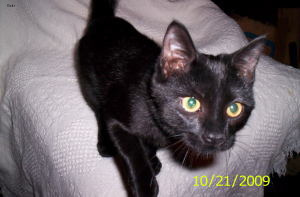

In [6]:
img = PILImage.create("/root/.fastai/data/oxford-iiit-pet/images/Bombay_64.jpg")
img

In [16]:
def categorize_pet(x):
    if x[0].isupper():
        return "cat"
    return "dog"

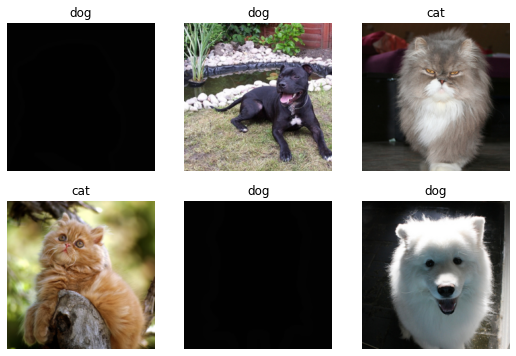

In [7]:

dls = ImageDataLoaders.from_name_func(
    path=pet_images,
    fnames=get_image_files(path),
    label_func=categorize_pet,
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224)
)
dls.show_batch(max_n=6)

In [8]:
learner = vision_learner(dls, resnet34, metrics=error_rate)
learner.fine_tune(2)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,0.394880,0.317589,0.161705,01:13


epoch,train_loss,valid_loss,error_rate,time
0,0.260335,0.174794,0.072057,01:39
1,0.164692,0.151173,0.061908,01:39


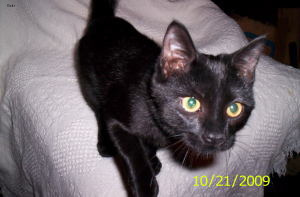

In [9]:
pet_images_list = list(pet_images.iterdir())
pet = pet_images_list[6]
img = PILImage.create(pet)
img

In [15]:
failed = verify_images(pet_images_list)
len(failed), len(pet_images_list)

(3, 7393)

In [10]:

a, b,c  = learner.predict(pet)
print(f"A: {a}")
print(f"B: {b}")
print(f"C: {c}")

A: cat
B: 0
C: tensor([1.0000e+00, 2.4565e-06])


# A cat-versus-dog classifier using the Oxford Pet dataset using datablock

[Link](https://www.robots.ox.ac.uk/~vgg/data/pets/)

Questions:
1. What are the inputs and targets? inputs are images; targets are text categories
2. Where does the data live? [here](https://www.robots.ox.ac.uk/~vgg/data/pets/) in the images folder
3. What needs to happen to the inputs? Check if the label is upper case. If so, it's a cat, else a dog.
4. What needs to happen to the targets? make them strings outputs with two options
5. How should I split the data? randomly with a seed of 42 for consistency across evaluations
6. What transforms should run on each item? Maybe resizing

7. What transforms should run on each batch? None

In [35]:
def categorize_pet(x):
    return "cat" if x.name[0].isupper() else "dog"

In [36]:
db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    item_tfms=Resize(224),
    splitter=RandomSplitter(seed=42),
    get_y=categorize_pet,
    get_items=get_image_files
)
dls = db.dataloaders(path/'images', bs=32)

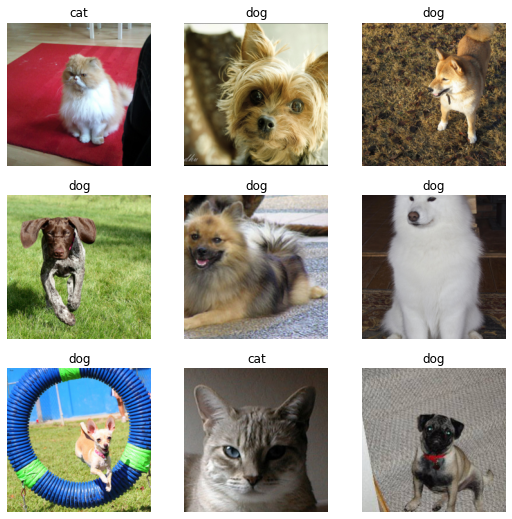

In [37]:
dls.show_batch()

In [38]:
learner = vision_learner(dls, resnet34, metrics=error_rate)
learner.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.112126,0.012214,0.004736,00:39


epoch,train_loss,valid_loss,error_rate,time
0,0.075456,0.018462,0.005413,00:53


/root/.fastai/data/oxford-iiit-pet/images/basset_hound_93.jpg


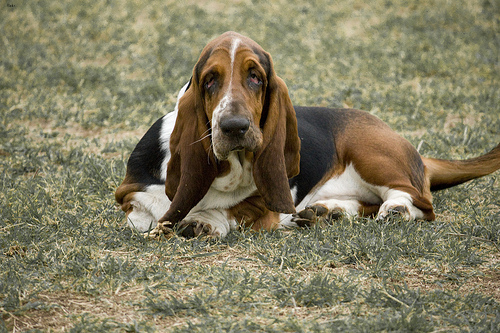

In [24]:
pet_images_list = list(pet_images.iterdir())
pet = pet_images_list[7]
print(pet)
img = PILImage.create(pet)
img

In [43]:
pred, _, probs = learner.predict(img)
print(f"PRED: {pred}")
print(f"PROBS: {probs}")

PRED: dog
PROBS: tensor([1.8793e-06, 1.0000e+00])


# 3. An animal breed classifier using the same dataset

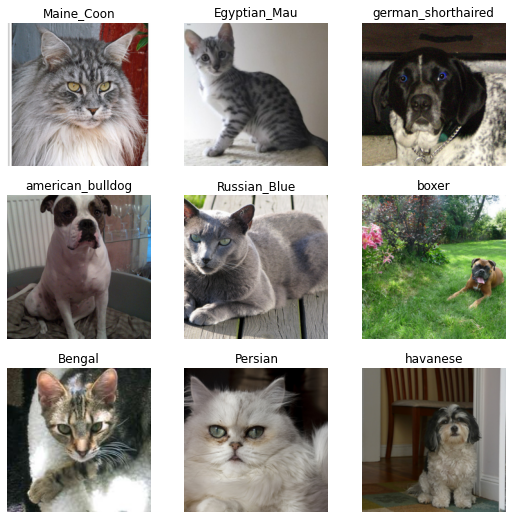

In [27]:
dls = ImageDataLoaders.from_path_re(
    path=pet_images,
    fnames=get_image_files(pet_images),
    pat=r"([^/]+)(?=_\d+\.jpg$)",
    bs=32,
    seed=42,
    item_tfms=Resize(224)
)
dls.show_batch()

In [25]:
import re

# 1. Compile a pattern to find 3 consecutive digits
# (Using 'r' indicates a raw string to handle backslashes properly)
digit_pattern = re.compile(r"([^/]+)(?=_\d+\.jpg$)")

# 2. Reuse the compiled object on different strings
match1 = digit_pattern.search("/root/.fastai/data/oxford-iiit-pet/images/basset_hound_93.jpg")

print(match1)
if match1:
    print(match1.group())  # Output: 456

<re.Match object; span=(42, 54), match='basset_hound'>
basset_hound


In [30]:
learner = vision_learner(dls, resnet34, metrics=error_rate)
learner.fine_tune(1)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,0.987072,0.333104,0.108254,00:39


epoch,train_loss,valid_loss,error_rate,time
0,0.541089,0.266168,0.090663,00:53


/root/.fastai/data/oxford-iiit-pet/images/Bombay_64.jpg


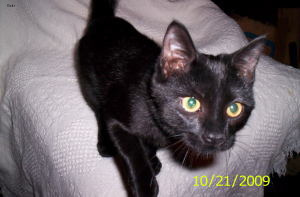

In [33]:
pet_images_list = list(pet_images.iterdir())
pet = pet_images_list[6]
print(pet)
img = PILImage.create(pet)
img

In [34]:
pred, _, probs = learner.predict(img)
print(f"PRED: {pred}")
print(f"PROBS: {probs}")

PRED: Bombay
PROBS: tensor([2.6315e-05, 8.6985e-06, 3.4673e-05, 9.9697e-01, 2.3055e-05, 5.0251e-06, 1.2531e-06, 2.3059e-06, 4.5020e-05, 2.7900e-04, 2.3399e-03, 1.1949e-05, 6.7677e-08, 5.0663e-06, 3.5649e-07, 2.6071e-07,
        8.3980e-07, 3.5439e-05, 7.6258e-07, 1.1937e-06, 1.1374e-05, 5.7680e-07, 1.6372e-07, 3.2205e-06, 1.8180e-06, 5.9211e-06, 2.5062e-05, 1.0023e-05, 9.6676e-06, 1.8139e-05, 6.2926e-07, 9.6097e-07,
        9.8408e-05, 1.3397e-05, 8.2172e-07, 1.2203e-06, 1.0364e-05])


## 2. DataBlock

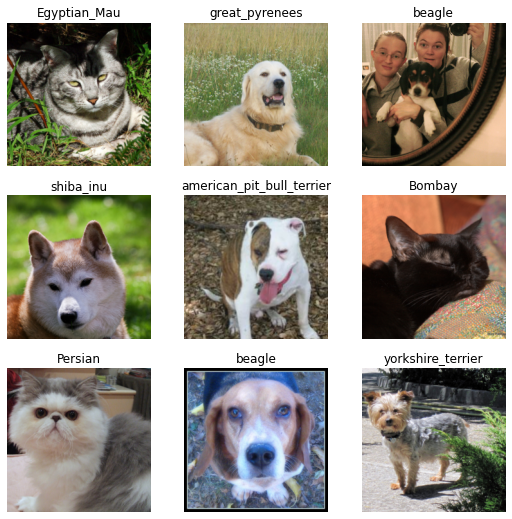

In [46]:
def get_y(x):
    digit_pattern = re.compile(r"([^/]+)(?=_\d+\.jpg$)")

#    print(f"Type: {type(x)}")
 #   print(f"Value: {x.name}")
    match1 = digit_pattern.search(x.name)
  #  print(f"MG: {match1.group()}")
    return match1.group()

db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    item_tfms=Resize(224),
    splitter=RandomSplitter(),
    get_y=get_y,#Pipeline([attrgetter("name"), RegexLabeller(pat=r"([^/]+)(?=_\d+\.jpg$)")]),
)
dls = db.dataloaders(pet_images, bs=32)
dls.show_batch()

In [41]:
learner = vision_learner(dls, resnet34, metrics=error_rate)
learner.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.972452,0.409186,0.121786,00:38


epoch,train_loss,valid_loss,error_rate,time
0,0.502378,0.269436,0.086604,00:53


/root/.fastai/data/oxford-iiit-pet/images/Bombay_64.jpg


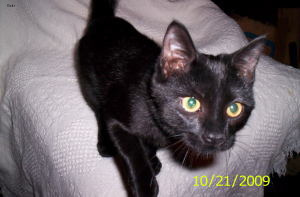

In [42]:
pet_images_list = list(pet_images.iterdir())
pet = pet_images_list[6]
print(pet)
img = PILImage.create(pet)
img

In [43]:
pred, _, probs = learner.predict(img)
print(f"PRED: {pred}")
print(f"PROBS: {probs}")

PRED: Bombay
PROBS: tensor([2.7581e-05, 9.8113e-07, 2.1933e-05, 9.9896e-01, 1.3048e-05, 1.8614e-06, 1.2447e-06, 1.5383e-07, 4.6687e-06, 6.0004e-04, 1.7475e-04, 4.3429e-07, 1.1376e-07, 2.4860e-06, 9.9673e-07, 2.5925e-07,
        8.1760e-07, 3.1541e-05, 1.7766e-06, 1.5090e-07, 2.2957e-06, 5.7554e-08, 1.1813e-06, 7.2947e-07, 6.1114e-07, 1.7069e-07, 4.4409e-05, 5.5243e-06, 1.0343e-05, 3.7188e-06, 1.0326e-07, 1.0199e-06,
        3.3984e-05, 3.5186e-06, 1.1099e-05, 8.2381e-08, 3.3690e-05])


# A multi-label vision classifier using the Pascal Dataset

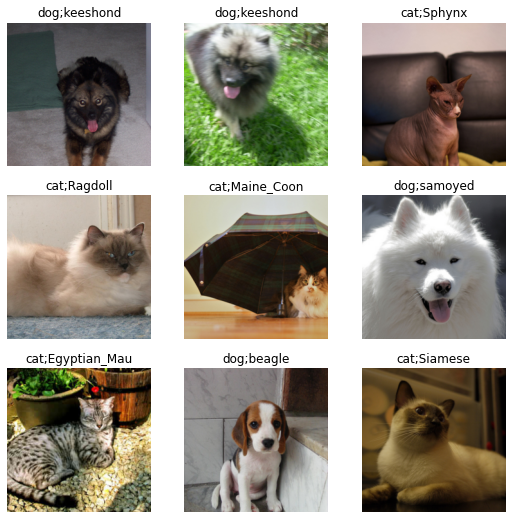

In [49]:
def get_y(x):
    digit_pattern = re.compile(r"([^/]+)(?=_\d+\.jpg$)")

#    print(f"Type: {type(x)}")
 #   print(f"Value: {x.name}")
    match1 = digit_pattern.search(x.name)
  #  print(f"MG: {match1.group()}")
    breed = match1.group()
    
    animal = "cat" if x.name[0].isupper() else "dog"
    return animal + ";" + breed

db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    item_tfms=Resize(224),
    splitter=RandomSplitter(),
    get_y=get_y,#Pipeline([attrgetter("name"), RegexLabeller(pat=r"([^/]+)(?=_\d+\.jpg$)")]),
)
dls = db.dataloaders(pet_images, bs=32)
dls.show_batch()

In [50]:
learner = vision_learner(dls, resnet34, metrics=error_rate)
learner.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,1.009012,0.360171,0.117050,00:38


epoch,train_loss,valid_loss,error_rate,time
0,0.475741,0.297492,0.091340,00:53


/root/.fastai/data/oxford-iiit-pet/images/Bombay_64.jpg


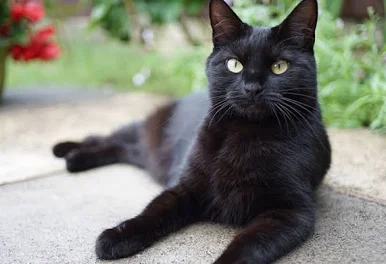

In [53]:
pet_images_list = list(pet_images.iterdir())
pet = pet_images_list[6]
print(pet)
pet = "./bombay-cat.webp"
img = PILImage.create(pet)
img

In [58]:
pred, ind, probs = learner.predict(img)
print(f"PRED: {pred}")
print(f"ind: {ind}")
print(f"PROBS: {probs[ind]}")

PRED: cat;Bombay
ind: 3
PROBS: 0.9960101842880249


# 4. A multi-label vision classifier using the Pascal Dataset ❌

[Link](https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/)

In [8]:
path = untar_data(URLs.PASCAL_2007)
(path).ls()

(#8) [Path('/root/.fastai/data/pascal_2007/test.json'),Path('/root/.fastai/data/pascal_2007/test.csv'),Path('/root/.fastai/data/pascal_2007/segmentation'),Path('/root/.fastai/data/pascal_2007/valid.json'),Path('/root/.fastai/data/pascal_2007/train'),Path('/root/.fastai/data/pascal_2007/test'),Path('/root/.fastai/data/pascal_2007/train.csv'),Path('/root/.fastai/data/pascal_2007/train.json')]

In [14]:
df = pd.read_csv(path/'train.csv')
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


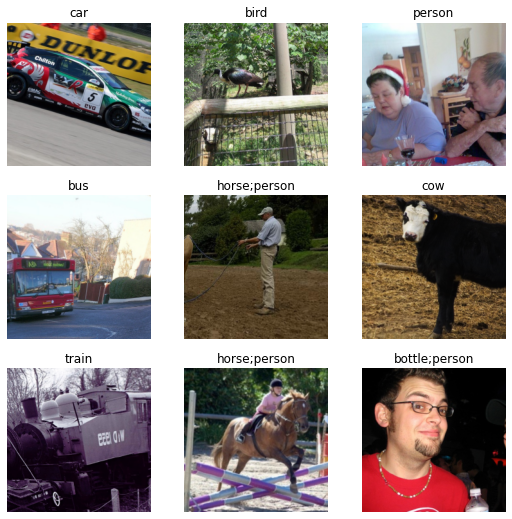

In [24]:
dls = ImageDataLoaders.from_df(
    df,
    path,
    folder='train',
    valid_col='is_valid',
    label_delim=' ',
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(size=224)
)

dls.show_batch()

In [26]:
learner = vision_learner(dls, resnet34)
learner.fine_tune(1)

epoch,train_loss,valid_loss,time
0,0.905631,0.583718,00:25


epoch,train_loss,valid_loss,time
0,0.662354,0.478402,00:31


SuggestedLRs(valley=0.0008317637839354575)

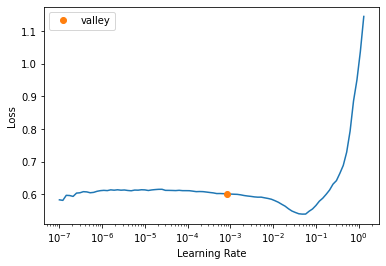

In [44]:
learner.lr_find()

In [73]:
f1_macro = F1ScoreMulti(thresh=0.5, average='macro')
f1_macro.name = "F1 (Macro)"
f1_samples = F1ScoreMulti(thresh=0.5, average='samples')
f1_samples.name = "F1 (Samples)"
learner = vision_learner(dls, resnet34, metrics=[partial(accuracy_multi, thresh=0.5), f1_macro, f1_samples])
learner.fine_tune(2, 8e-3)

epoch,train_loss,valid_loss,accuracy_multi,F1 (Macro),F1 (Samples),time
0,0.703345,0.195697,0.945458,0.630492,0.705103,00:24


epoch,train_loss,valid_loss,accuracy_multi,F1 (Macro),F1 (Samples),time
0,0.162544,0.109981,0.961873,0.638037,0.680502,00:30
1,0.120663,0.088108,0.969283,0.737812,0.760675,00:30


/root/.fastai/data/pascal_2007/train/007900.jpg


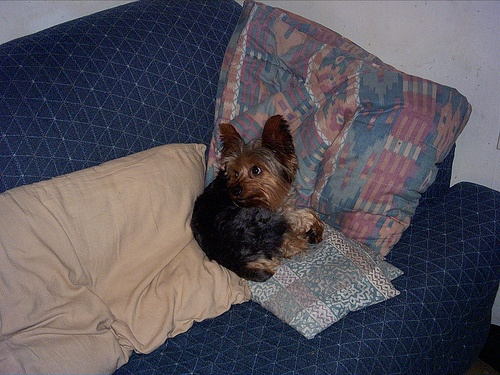

In [84]:
pascal_images_list = list((path/'train').iterdir())
pascal_img = pascal_images_list[101]
print(pascal_img)
img = PILImage.create(pascal_img)
img

In [85]:
pred, ind, probs = learner.predict(img)
print(f"PRED: {pred}")
print(f"ind: {ind}")
print(f"PROBS: {probs[ind]}")

PRED: ['dog', 'sofa']
ind: tensor([False, False, False, False, False, False, False, False, False, False, False,  True, False, False, False, False, False,  True, False, False])
PROBS: tensor([0.9985, 0.8141])


# A bird image classifier using images found through DuckDuckGo (Link) ❌

In [7]:
from ddgs import DDGS

In [8]:
def search_images(query, max_images=100):
    results = DDGS().images(
        query=query,
        region="wt-wt",
        safesearch="off",
        #size=None,
        #color="Monochrome",
        type_image=None,
        layout=None,
        license_image=None,
        max_results=max_images,
    )
    return [result['image'] for result in results if 'image' in result]

In [9]:
searches = 'bird', 'dog'
parent_dir = Path('test')
for search in searches:
    # get images
    imgs = search_images(query=search + "photo")
    # new path
    p = parent_dir / search
    # make director
    p.mkdir(parents=True, exist_ok=True)
    # download images into it
    download_images(p, urls=imgs)
    resize_images(p, max_size=400, dest=p)

In [10]:
failed = verify_images(get_image_files(parent_dir))
failed.map(Path.unlink)
len(failed)

22

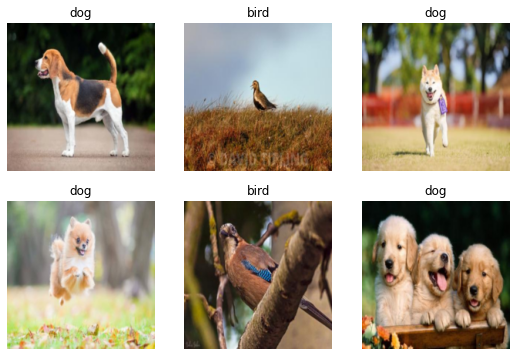

In [11]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(parent_dir)

dls.show_batch(max_n=6)

In [12]:
learner = vision_learner(dls, resnet34, metrics=error_rate)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

SuggestedLRs(valley=0.0005754399462603033)

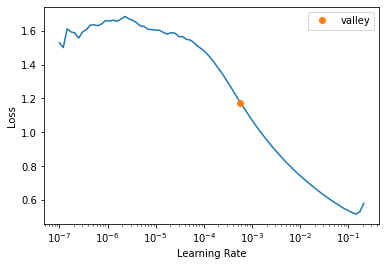

In [13]:
learner.lr_find()

In [17]:
learner.fine_tune(4, 5e-3)

epoch,train_loss,valid_loss,error_rate,time
0,0.549608,0.348068,0.206897,00:01


epoch,train_loss,valid_loss,error_rate,time
0,0.309547,0.124427,0.034483,00:02
1,0.210768,0.028941,0.000000,00:02
2,0.146069,0.032057,0.034483,00:02
3,0.110072,0.030999,0.034483,00:02


In [18]:
fs = get_image_files(parent_dir)
len(fs), fs[0]

(146, Path('test/dog/c30ef5cf-7b0e-4fc2-be19-75c894ee0422.jpg'))

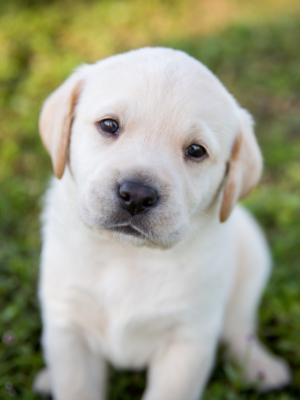

In [19]:
img = PILImage.create(fs[0])
img

In [20]:
preds, indx, probs = learner.predict(img)
print(f"preds: {preds}")
print(f"probs: {probs[indx]}")

preds: dog
probs: 0.9999998807907104


# A tabular model using the Adult dataset to predict income above or below $50,000

In [21]:
path = untar_data(URLs.ADULT_SAMPLE)
path.ls()

(#3) [Path('/root/.fastai/data/adult_sample/models'),Path('/root/.fastai/data/adult_sample/export.pkl'),Path('/root/.fastai/data/adult_sample/adult.csv')]

In [22]:
df = pd.read_csv('/root/.fastai/data/adult_sample/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,49,Private,101320,Assoc-acdm,12.0,Married-civ-spouse,NaN,Wife,White,Female,0,1902,40,United-States,>=50k
1,44,Private,236746,Masters,14.0,Divorced,Exec-managerial,Not-in-family,White,Male,10520,0,45,United-States,>=50k
2,38,Private,96185,HS-grad,NaN,Divorced,NaN,Unmarried,Black,Female,0,0,32,United-States,<50k
3,38,Self-emp-inc,112847,Prof-school,15.0,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,40,United-States,>=50k
4,42,Self-emp-not-inc,82297,7th-8th,NaN,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,50,United-States,<50k


In [27]:
from fastai.tabular.all import *

In [28]:
dls = TabularDataLoaders.from_df(
    df=df,
    cat_names = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race'],
    cont_names = ['age', 'fnlwgt', 'education-num'],
    procs = [Categorify, FillMissing, Normalize],
    y_names="salary", 
    valid_idx=list(range(800,1000)), 
    bs=64
)

In [30]:
dls.show_batch()

,workclass,education,marital-status,occupation,relationship,race,education-num_na,age,fnlwgt,education-num,salary
0,Private,Some-college,Married-civ-spouse,Craft-repair,Husband,White,False,29.000000,130855.999710,10.0,<50k
1,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,False,43.000000,54610.998016,9.0,<50k
2,?,11th,Never-married,?,Own-child,White,False,18.000000,115257.997501,7.0,<50k
3,State-gov,Bachelors,Married-civ-spouse,Tech-support,Husband,White,False,23.000000,33550.997709,13.0,<50k
4,Private,HS-grad,Never-married,Sales,Not-in-family,White,False,18.000000,181754.999864,9.0,<50k
5,Private,Bachelors,Never-married,#na#,Not-in-family,White,False,31.000000,255004.000864,13.0,<50k
6,Private,11th,Never-married,Handlers-cleaners,Own-child,White,False,18.000000,238866.999044,7.0,<50k
7,Private,11th,Never-married,Handlers-cleaners,Unmarried,White,False,26.000000,245628.000286,7.0,<50k
8,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,Black,False,39.000000,288550.999422,9.0,<50k
9,Federal-gov,11th,Widowed,Adm-clerical,Not-in-family,White,False,68.999999,143848.998494,7.0,<50k


In [36]:
learner = tabular_learner(dls, metrics=accuracy)

SuggestedLRs(valley=0.0008317637839354575)

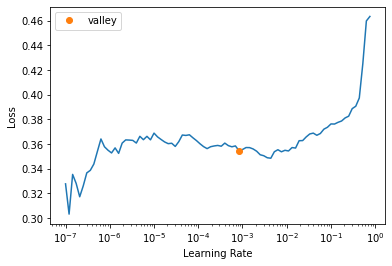

In [38]:
learner.lr_find()

In [40]:
learner.fit_one_cycle(5, lr_max=8e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.366402,0.384050,0.790000,00:05
1,0.357886,0.383660,0.830000,00:05
2,0.360303,0.365445,0.855000,00:04
3,0.346097,0.363187,0.850000,00:05
4,0.340713,0.371727,0.850000,00:05


In [46]:
item = df.iloc[2]
preds, idx, probs = learner.predict(item)
print(f"preds: {preds}")
print(f"probs: {probs[idx]}")

preds:    workclass  education  marital-status  occupation  relationship  race  \
0        5.0       12.0             1.0         0.0           5.0   3.0   

   education-num_na       age    fnlwgt  education-num  salary  
0               2.0 -0.043043 -0.886805      -0.031209     0.0  
probs: 0.9632437825202942


In [47]:
item

age                           38
workclass                Private
fnlwgt                     96185
education                HS-grad
education-num                NaN
marital-status          Divorced
occupation                   NaN
relationship           Unmarried
race                       Black
sex                       Female
capital-gain                   0
capital-loss                   0
hours-per-week                32
native-country     United-States
salary                      <50k
Name: 2, dtype: object

In [48]:
preds.show()

,workclass,education,marital-status,occupation,relationship,race,education-num_na,age,fnlwgt,education-num,salary
0,Private,HS-grad,Divorced,#na#,Unmarried,Black,True,38.0,96185.001882,10.0,<50k


# A movie recommender using collaborative filtering and the Movielens 100k data dataset

In [5]:
path = untar_data(URLs.ML_SAMPLE)
path.ls()

(#1) [Path('/root/.fastai/data/movie_lens_sample/ratings.csv')]

In [6]:
from fastai.collab import *

In [8]:
ratings = pd.read_csv(path/'ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,73,1097,4.0,1255504951
1,561,924,3.5,1172695223
2,157,260,3.5,1291598691
3,358,1210,5.0,957481884
4,130,316,2.0,1138999234


In [9]:
dls = CollabDataLoaders.from_df(ratings, bs=64)
dls.show_batch()

,userId,movieId,rating
0,561,2028,3.5
1,212,1200,3.0
2,30,539,3.0
3,457,1732,3.0
4,157,58559,4.5
5,596,4973,5.0
6,561,5952,5.0
7,358,357,5.0
8,111,39,4.5
9,242,296,5.0


In [10]:
ratings['rating'].min(),ratings['rating'].max()

(0.5, 5.0)

In [11]:
learn = collab_learner(dls, y_range=(0.5,5))

SuggestedLRs(valley=0.007585775572806597)

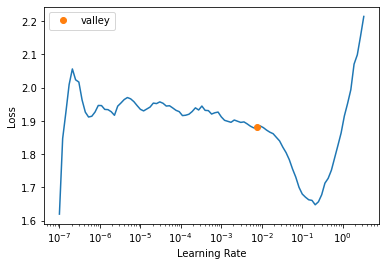

In [26]:
learn.lr_find()

In [29]:
learn.fit_one_cycle(1, 7e-2)

epoch,train_loss,valid_loss,time
0,1.144094,1.472548,00:00


In [30]:
learn.show_results(max_n=10)

,userId,movieId,rating,rating_pred
0,67.0,24.0,3.0,1.526029
1,89.0,6.0,4.0,4.988178
2,88.0,56.0,4.5,4.044957
3,80.0,44.0,3.0,3.761317
4,95.0,10.0,2.5,2.194671
5,13.0,37.0,4.0,4.600657
6,60.0,52.0,5.0,4.934031
7,80.0,25.0,3.0,4.012706
8,65.0,7.0,4.0,4.233212
9,8.0,96.0,4.0,4.759385


# An image segmentation model using UNet and the Camvid dataset

In [15]:
path = untar_data(URLs.CAMVID_TINY)
path.ls()

(#3) [Path('/root/.fastai/data/camvid_tiny/images'),Path('/root/.fastai/data/camvid_tiny/codes.txt'),Path('/root/.fastai/data/camvid_tiny/labels')]

In [19]:
codes = np.loadtxt(path/'codes.txt', dtype="str")
codes

array(['Animal', 'Archway', 'Bicyclist', 'Bridge', 'Building', 'Car', 'CartLuggagePram', 'Child', 'Column_Pole', 'Fence', 'LaneMkgsDriv', 'LaneMkgsNonDriv', 'Misc_Text', 'MotorcycleScooter',
       'OtherMoving', 'ParkingBlock', 'Pedestrian', 'Road', 'RoadShoulder', 'Sidewalk', 'SignSymbol', 'Sky', 'SUVPickupTruck', 'TrafficCone', 'TrafficLight', 'Train', 'Tree', 'Truck_Bus', 'Tunnel',
       'VegetationMisc', 'Void', 'Wall'], dtype='<U17')

In [22]:
def label_func(fn): return path/'labels'/f'{fn.stem}_P{fn.suffix}'

In [25]:
fnames = get_image_files(path/'images')
dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames = fnames, label_func = label_func, codes = codes
)

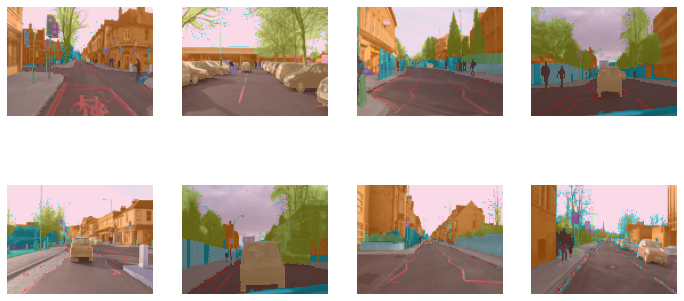

In [26]:
dls.show_batch()

In [27]:
learn = unet_learner(dls, resnet34)
learn.fine_tune(6)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,time
0,2.791293,3.218190,00:04


epoch,train_loss,valid_loss,time
0,2.114458,1.810540,00:02
1,1.788620,1.527956,00:02
2,1.601129,1.166068,00:02
3,1.422124,1.080310,00:02
4,1.275700,1.023506,00:02
5,1.161089,0.983986,00:02


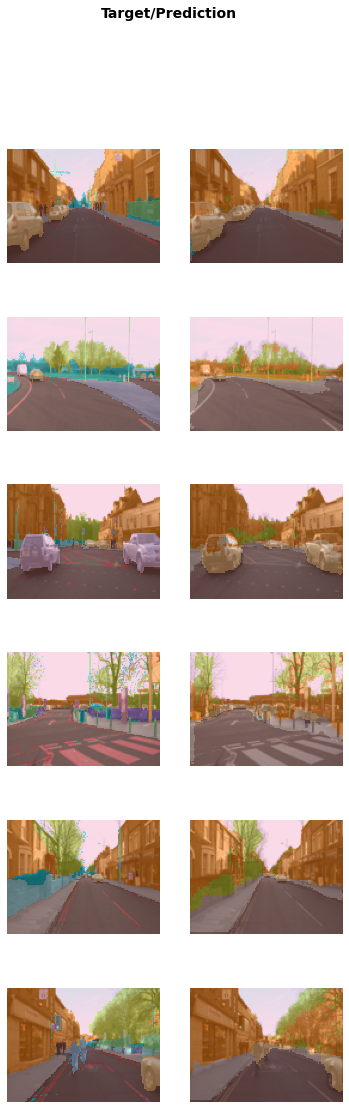

In [28]:
learn.show_results(max_n=6)

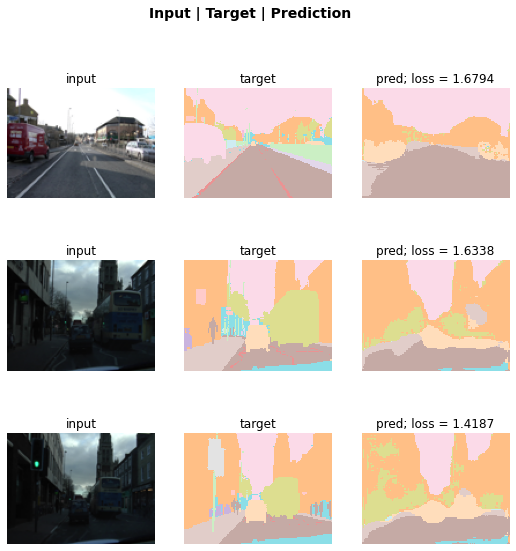

In [29]:
interp = SegmentationInterpretation.from_learner(learn)
interp.plot_top_losses(k=3)

# Text data loader

In [4]:
from fastai.text.all import *

In [5]:
path = untar_data(URLs.IMDB_SAMPLE)
path.ls()

(#1) [Path('/root/.fastai/data/imdb_sample/texts.csv')]

In [6]:
data = pd.read_csv(path/'texts.csv')
data.head()

,label,text,is_valid
0,negative,"Un-bleeping-believable! Meg Ryan doesn't even look her usual pert lovable self in this, which normally makes me forgive her shallow ticky acting schtick. Hard to believe she was the producer on this dog. Plus Kevin Kline: what kind of suicide trip has his career been on? Whoosh... Banzai!!! Finally this was directed by the guy who did Big Chill? Must be a replay of Jonestown - hollywood style. Wooofff!",False
1,positive,"This is a extremely well-made film. The acting, script and camera-work are all first-rate. The music is good, too, though it is mostly early in the film, when things are still relatively cheery. There are no really superstars in the cast, though several faces will be familiar. The entire cast does an excellent job with the script.<br /><br />But it is hard to watch, because there is no good end to a situation like the one presented. It is now fashionable to blame the British for setting Hindus and Muslims against each other, and then cruelly separating them into two countries. There is som...",False
2,negative,"Every once in a long while a movie will come along that will be so awful that I feel compelled to warn people. If I labor all my days and I can save but one soul from watching this movie, how great will be my joy.<br /><br />Where to begin my discussion of pain. For starters, there was a musical montage every five minutes. There was no character development. Every character was a stereotype. We had swearing guy, fat guy who eats donuts, goofy foreign guy, etc. The script felt as if it were being written as the movie was being shot. The production value was so incredibly low that it felt li...",False
3,positive,"Name just says it all. I watched this movie with my dad when it came out and having served in Korea he had great admiration for the man. The disappointing thing about this film is that it only concentrate on a short period of the man's life - interestingly enough the man's entire life would have made such an epic bio-pic that it is staggering to imagine the cost for production.<br /><br />Some posters elude to the flawed characteristics about the man, which are cheap shots. The theme of the movie ""Duty, Honor, Country"" are not just mere words blathered from the lips of a high-brassed offic...",False
4,negative,"This movie succeeds at being one of the most unique movies you've seen. However this comes from the fact that you can't make heads or tails of this mess. It almost seems as a series of challenges set up to determine whether or not you are willing to walk out of the movie and give up the money you just paid. If you don't want to feel slighted you'll sit through this horrible film and develop a real sense of pity for the actors involved, they've all seen better days, but then you realize they actually got paid quite a bit of money to do this and you'll lose pity for them just like you've alr...",False


In [7]:
dls = TextDataLoaders.from_df(
    df=data,
    text_col='text',
    label_col='label',
    valid_col='is_valid',
    seed=42,
    bs=8
)

In [8]:
dls.show_batch(max_n=6)

,text,category
0,"xxbos xxmaj raising xxmaj victor xxmaj vargas : a xxmaj review \n\n xxmaj you know , xxmaj raising xxmaj victor xxmaj vargas is like sticking your hands into a big , xxunk bowl of xxunk . xxmaj it 's warm and gooey , but you 're not sure if it feels right . xxmaj try as i might , no matter how warm and gooey xxmaj raising xxmaj victor xxmaj vargas became i was always aware that something did n't quite feel right . xxmaj victor xxmaj vargas suffers from a certain xxunk on the director 's part . xxmaj apparently , the director thought that the ethnic backdrop of a xxmaj latino family on the lower east side , and an xxunk storyline would make the film critic proof . xxmaj he was right , but it did n't fool me . xxmaj raising xxmaj victor xxmaj vargas is",negative
1,"xxbos xxup the xxup shop xxup around xxup the xxup corner is one of the xxunk and most feel - good romantic comedies ever made . xxmaj there 's just no getting around that , and it 's hard to actually put one 's feeling for this film into words . xxmaj it 's not one of those films that tries too hard , nor does it come up with the xxunk possible scenarios to get the two protagonists together in the end . xxmaj in fact , all its charm is xxunk , contained within the characters and the setting and the plot … which is highly believable to xxunk . xxmaj it 's easy to think that such a love story , as beautiful as any other ever told , * could * happen to you … a feeling you do n't often get from other romantic comedies",positive
2,"xxbos xxmaj now that xxmaj che(2008 ) has finished its relatively short xxmaj australian cinema run ( extremely limited xxunk screen in xxmaj xxunk , after xxunk ) , i can xxunk join both xxunk of "" at xxmaj the xxmaj movies "" in taking xxmaj steven xxmaj soderbergh to task . \n\n xxmaj it 's usually satisfying to watch a film director change his style / subject , but xxmaj soderbergh 's most recent stinker , xxmaj the xxmaj girlfriend xxmaj xxunk ) , was also missing a story , so narrative ( and editing ? ) seem to suddenly be xxmaj soderbergh 's main challenge . xxmaj strange , after 20 - odd years in the business . xxmaj he was probably never much good at narrative , just xxunk it well inside "" edgy "" projects . \n\n xxmaj none of this excuses him this present ,",negative
3,"xxbos xxmaj the year 2005 saw no xxunk than 3 filmed productions of xxup h. xxup g. xxmaj wells ' great novel , "" war of the xxmaj worlds "" . xxmaj this is perhaps the least well - known and very probably the best of them . xxmaj no other version of xxunk has ever attempted not only to present the story very much as xxmaj wells wrote it , but also to create the atmosphere of the time in which it was supposed to take place : the last year of the 19th xxmaj century , 1900 ▁ using xxmaj wells ' original setting , in and near xxmaj xxunk , xxmaj england . \n\n imdb seems xxunk to what they regard as "" spoilers "" . xxmaj that might apply with some films , where the ending might actually be a surprise , but with regard to",positive
4,"xxbos xxmaj well , what can i say . \n\n "" what the xxmaj xxunk do we xxmaj know "" has achieved the nearly impossible - leaving behind such masterpieces of the genre as "" the xxmaj xxunk "" , "" the xxmaj xxunk xxmaj master "" , "" xxunk "" , and so fourth , it will go down in history as the single worst movie i have ever seen in its xxunk . xxmaj and that , ladies and gentlemen , is impressive indeed , for i have seen many a bad movie . \n\n xxmaj this masterpiece of modern cinema consists of two xxunk parts , xxunk between a silly and contrived plot about an extremely annoying photographer , abandoned by her husband and forced to take anti - xxunk to survive , and a bunch of talking heads going on about how quantum physics supposedly xxunk",negative
5,"xxbos xxmaj although recognized as the best film treatment of the difficulties of having a house in the country built ( or bought ) to your xxunk , it is not the firs

In [11]:
learner = text_classifier_learner(dls=dls, arch=AWD_LSTM, metrics=accuracy)

SuggestedLRs(valley=0.0030199517495930195)

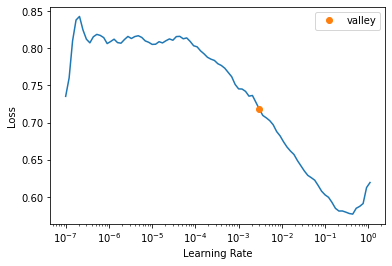

In [43]:
learner.lr_find()

In [9]:
!nvidia-smi

Thu Aug  6 00:47:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro P4000                   Off |   00000000:00:05.0 Off |                  N/A |
| 52%   46C    P0             28W /  105W |     557MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
learner.fine_tune(3, 3e-4)

epoch,train_loss,valid_loss,accuracy,time
0,0.688328,0.598461,0.685000,00:21


epoch,train_loss,valid_loss,accuracy,time
0,0.579326,0.540729,0.730000,00:36
1,0.551498,0.508026,0.765000,00:36
2,0.480572,0.510350,0.770000,00:36


In [13]:
learner.show_results(max_n=3)

,text,category,category_
0,"xxbos xxmaj i 'm sure things did n't exactly go the same way in the real life of xxmaj homer xxmaj hickam as they did in the film adaptation of his book , xxmaj rocket xxmaj boys , but the movie "" october xxmaj sky "" ( an xxunk of the book 's title ) is good enough to stand alone . i have not read xxmaj hickam 's memoirs , but i am still able to enjoy and understand their film adaptation . xxmaj the film , directed by xxmaj joe xxmaj xxunk and written by xxmaj lewis xxmaj xxunk , xxunk the story of teenager xxmaj homer xxmaj hickam ( jake xxmaj xxunk ) , beginning in xxmaj october of 1957 . xxmaj it opens with the sound of a radio broadcast , bringing news of the xxmaj russian satellite xxmaj xxunk , the first artificial satellite in",positive,positive
1,"xxbos xxmaj to review this movie , i without any doubt would have to quote that memorable scene in xxmaj tarantino 's "" pulp xxmaj fiction "" ( xxunk ) when xxmaj jules and xxmaj vincent are talking about xxmaj mia xxmaj wallace and what she does for a living . xxmaj jules tells xxmaj vincent that the "" only thing she did worthwhile was pilot "" . xxmaj vincent asks "" what the hell is a pilot ? "" and xxmaj jules goes into a very well description of what a xxup tv pilot is : "" well , the way they make shows is , they make one show . xxmaj that show 's called a ' pilot ' . xxmaj then they show that show to the people who make shows , and on the strength of that one show they decide if they 're going to",negative,negative
2,"xxbos xxmaj how viewers react to this new "" adaption "" of xxmaj shirley xxmaj jackson 's book , which was promoted as xxup not being a remake of the original 1963 movie ( true enough ) , will be based , i suspect , on the following : those who were big fans of either the book or original movie are not going to think much of this one … and those who have never been exposed to either , and who are big fans of xxmaj hollywood 's current trend towards "" special effects "" being the first and last word in how "" good "" a film is , are going to love it . \n\n xxmaj things i did not like about this adaption : \n\n 1 . xxmaj it was xxup not a true adaption of the book . xxmaj from the xxunk i had",negative,negative


In [1]:
preds, idx, probs = learner.predict("I didn't liked that show")
print(f"preds: {preds}")
print(f"probs: {probs[idx]}")

NameError: name 'learner' is not defined